In [8]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
from sklearn.model_selection import train_test_split

In [9]:
data = pd.read_csv("insurance.csv")

X = data.drop(columns=["charges"])
y = data["charges"]

X = pd.get_dummies(X, columns=["region"], drop_first = False, dtype = int)

X["sex"] = X["sex"].map({"female":1, "male":0})
X["smoker"] = X["smoker"].map({"yes":1, "no":0})

X["age_smoker"] = X["age"] * X["smoker"]
X["bmi_smoker"] = X["bmi"] * X["smoker"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state = 42)

MSE for aplha = 0.001:  20922596.528006196
MSE for aplha = 0.1:  20921899.28756773
MSE for aplha = 1:  20915761.347724438
MSE for aplha = 2:  20909904.882848237
MSE for aplha = 5:  20894930.88738714
MSE for aplha = 10:  20879460.429074306
MSE for aplha = 20:  20885116.385373846
MSE for aplha = 30:  20939554.097556513
MSE for aplha = 40:  21030365.00375737
MSE for aplha = 50:  21137371.39625106


<Axes: >

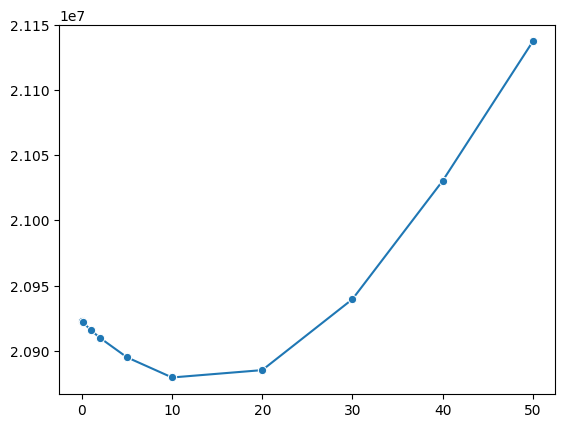

In [10]:
import seaborn as sns

alphas = [0.001,0.1,1,2,5,10,20,30,40,50]
mses = []

for a in alphas:

    lasso_model = Lasso(alpha = a)
    lasso_model.fit(X_train, y_train)
    
    y_pred = lasso_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    
    print(f"MSE for aplha = {a}: ",mse)

    mses.append(mse)

sns.lineplot(x = alphas, y = mses, marker="o")

In [11]:
from sklearn.linear_model import LassoCV

a = [0.001,0.1,1,2,5,10,20,30,40,50,100]

lasso_cv_model = LassoCV(
    alphas = a,
    cv = 5,
    max_iter = 1000,
    random_state = 42
)
lasso_cv_model.fit(X_train, y_train)
print("best alpha:", lasso_cv_model.alpha_)

y_pred = lasso_cv_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("mse = ",mse)
print("r2 = ",r2)

best alpha: 0.001
mse =  20922596.528006196
r2 =  0.8652317714485489


In [12]:
from sklearn.linear_model import RidgeCV

a = [0.001,0.1,1,2,5,10,20,30,40,50,100]

ridge_cv_model = RidgeCV(
    alphas = a,
    cv = 5,
)
ridge_cv_model.fit(X_train, y_train)
print("best alpha:", ridge_cv_model.alpha_)

y_pred = ridge_cv_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("mse = ",mse)
print("r2 = ",r2)

best alpha: 0.001
mse =  20922416.32007051
r2 =  0.8652329322176834
